# **Evaluación Sumativa Unidad 02: Inferencia Estadística y Diagnóstico Paramétrico (ABP)**
# 🧠 **Estudiante:** Alison Tapia

-----------------

## 📝 **Introducción**

El presente cuaderno consolida las últimas fronteras de la unidad de Inferencia Estadística aplicadas al dataset regional de casos de dengue del Ministerio de Salud Pública (MSP), correspondiente a la provincia de **Loja** (periodo 2021 - 2025).

Se desarrollan tres bloques de análisis:

1. **Prueba de Hipótesis Unimuestral:** se contrasta un parámetro crítico de la región de Loja (la edad promedio de los pacientes con dengue) frente a un valor de referencia, utilizando la prueba **T de Student**.
2. **Comparación de Grupos:** el dataset regional se divide en subgrupos según el **cantón de domicilio** del paciente (entendidos como distintos sectores/microclimas de la provincia de Loja). Se implementa:
   * Un **A/B Testing** (prueba T para dos muestras independientes) entre los dos cantones con mayor número de casos.
   * Un **Análisis de Varianza (ANOVA de 1 factor)** entre los cinco cantones con mayor representación muestral, acompañado de la prueba **Post-Hoc de Tukey**.
3. **Formalismo estadístico:** todo el análisis se apoya en las abstracciones de `scipy.stats` y `statsmodels`, con verificación de supuestos (normalidad y homocedasticidad), documentación en cada bloque de código y formalización matemática mediante ecuaciones en LaTeX.


---
# **📂 Sección 0: Configuración y Carga de Datos**


In [2]:
# ==========================================================
# LIBRERÍAS
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, levene, shapiro, f_oneway, kruskal

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")

# ==========================================================
# CARGA DEL DATASET REGIONAL (CASOS INDIVIDUALES DE DENGUE)
# ==========================================================

archivo = "Datos_Dengue_MSP_Ene2021_Ago2025.xlsx"

df = pd.read_excel(archivo, sheet_name="DCSA_DG_2021_2025")

# Limpieza de nombres de columnas (algunas traen espacios extra)
df.columns = [c.strip() for c in df.columns]

# ----------------------------------------------------------
# Filtrado: región de estudio = provincia de Loja
# ----------------------------------------------------------
df_loja = df[df["Prov Domic"].astype(str).str.contains("LOJA", case=False, na=False)].copy()

# Limpieza de la variable cuantitativa "Edad"
df_loja["Edad"] = pd.to_numeric(df_loja["Edad"], errors="coerce")
df_loja = df_loja.dropna(subset=["Edad", "Canton  Domic"])
df_loja["Canton  Domic"] = df_loja["Canton  Domic"].astype(str).str.strip()

print("=" * 65)
print(" DATASET REGIONAL - PROVINCIA DE LOJA (Casos de Dengue) ")
print("=" * 65)
print(f"Número total de casos registrados en Loja : {len(df_loja)}")
print(f"Rango de años                              : {df_loja['Año'].min()} - {df_loja['Año'].max()}")
print("\nDistribución de casos por cantón (sector):")
print(df_loja["Canton  Domic"].value_counts())


 DATASET REGIONAL - PROVINCIA DE LOJA (Casos de Dengue) 
Número total de casos registrados en Loja : 350
Rango de años                              : 2021 - 2025

Distribución de casos por cantón (sector):
Canton  Domic
MACARA          167
CATAMAYO        106
LOJA             23
ZAPOTILLO        18
PALTAS            9
CELICA            6
PINDAL            5
SARAGURO          4
PUYANGO           4
CALVAS            4
SOZORANGA         2
CHAGUARPAMBA      1
ESPINDOLA         1
Name: count, dtype: int64


---
# **🛠️ Tarea 1: Prueba de Hipótesis Unimuestral (T de Student)**

### Planteamiento del problema

Se desea evaluar si la **edad promedio de los pacientes con dengue en la provincia de Loja** difiere del valor de referencia observado a nivel nacional en estudios previos ($\mu_0 = 30$ años).

Dado que la desviación estándar poblacional ($\sigma$) **no es conocida** y debe estimarse a partir de la muestra, corresponde utilizar la **prueba T de Student** en lugar de la prueba Z, incluso tratándose de un tamaño de muestra moderado/grande.

### Hipótesis estadísticas

$$
H_0: \mu = 30 \quad \text{(la edad promedio de los casos de dengue en Loja es igual a 30 años)}
$$

$$
H_1: \mu \neq 30 \quad \text{(la edad promedio de los casos de dengue en Loja difiere de 30 años)}
$$

Prueba bilateral, con nivel de significancia $\alpha = 0.05$.

### Estadístico de prueba

$$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \qquad gl = n-1
$$

donde $\bar{x}$ es la media muestral, $s$ la desviación estándar muestral y $n$ el tamaño de la muestra.

### Regla de decisión

Se rechaza $H_0$ si el **Valor-p** obtenido es menor que $\alpha = 0.05$.

   PRUEBA T DE STUDENT — EDAD PROMEDIO DE CASOS DE DENGUE EN LOJA

Hipótesis:
  H0 : mu = 30
  H1 : mu != 30

Estadísticos descriptivos:
  Tamaño de muestra (n)     = 350
  Media muestral (x̄)        = 29.1457 años
  Desv. estándar (s)        = 20.3754
  Error estándar            = 1.0891
  Grados de libertad (gl)   = 349

Resultados de la prueba:
  Estadístico t             = -0.7844
  Valor crítico ±t(a/2)     = ±1.9668
  Valor-p (bilateral)       = 0.433344

Decisión:
  No se rechaza la hipótesis nula (H0)


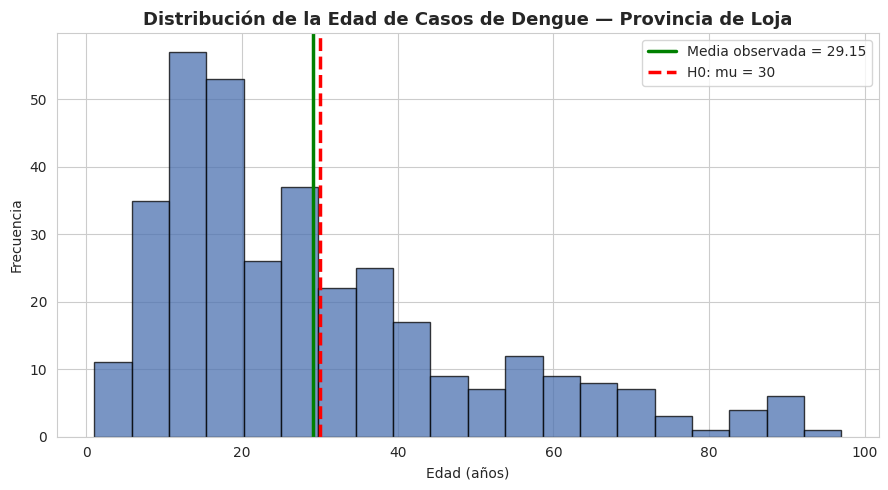

In [ ]:
# ==========================================================
# PRUEBA T DE STUDENT PARA UNA MEDIA (EDAD PROMEDIO EN LOJA)
# ==========================================================

mu_0 = 30      # Valor de referencia (parámetro hipotético)
alpha = 0.05   # Nivel de significancia

edades_loja = df_loja["Edad"].values

# ----------------------------------------------------------
# Estadísticos descriptivos
# ----------------------------------------------------------
n = len(edades_loja)
media = np.mean(edades_loja)
desv_std = np.std(edades_loja, ddof=1)
error_estandar = desv_std / np.sqrt(n)
gl = n - 1

# ----------------------------------------------------------
# Prueba T bilateral (abstracción de scipy.stats)
# ----------------------------------------------------------
t_calculado, p_valor = ttest_1samp(edades_loja, popmean=mu_0, alternative="two-sided")

t_critico = stats.t.ppf(1 - alpha / 2, df=gl)
rechazar_h0 = p_valor < alpha

# ----------------------------------------------------------
# Resultados
# ----------------------------------------------------------
print("=" * 65)
print("   PRUEBA T DE STUDENT — EDAD PROMEDIO DE CASOS DE DENGUE EN LOJA")
print("=" * 65)

print("\nHipótesis:")
print(f"  H0 : mu = {mu_0}")
print(f"  H1 : mu != {mu_0}")

print("\nEstadísticos descriptivos:")
print(f"  Tamaño de muestra (n)     = {n}")
print(f"  Media muestral (x̄)        = {media:.4f} años")
print(f"  Desv. estándar (s)        = {desv_std:.4f}")
print(f"  Error estándar            = {error_estandar:.4f}")
print(f"  Grados de libertad (gl)   = {gl}")

print("\nResultados de la prueba:")
print(f"  Estadístico t             = {t_calculado:.4f}")
print(f"  Valor crítico ±t(a/2)     = ±{t_critico:.4f}")
print(f"  Valor-p (bilateral)       = {p_valor:.6f}")

print("\nDecisión:")
if rechazar_h0:
    print("  Se RECHAZA la hipótesis nula (H0)")
else:
    print("  No se rechaza la hipótesis nula (H0)")
print("=" * 65)

# ----------------------------------------------------------
# Gráfico de apoyo
# ----------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.hist(edades_loja, bins=20, edgecolor="black", alpha=0.75, color="#4C72B0")
plt.axvline(media, color="green", linestyle="-", linewidth=2.5, label=f"Media observada = {media:.2f}")
plt.axvline(mu_0, color="red", linestyle="--", linewidth=2.5, label=f"H0: mu = {mu_0}")
plt.title("Distribución de la Edad de Casos de Dengue — Provincia de Loja", fontsize=13, fontweight="bold")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


### **Interpretación**

Se aplicó una prueba T de Student de una muestra para evaluar si la edad promedio de los casos de dengue en la provincia de Loja es de 30 años. Con un nivel de significancia $\alpha = 0.05$, se obtuvo un Valor-p de aproximadamente **0.4333**, muy superior al umbral de significancia.

Dado que el Valor-p > $\alpha$, **no se rechaza $H_0$**. Es decir, no existe evidencia estadística suficiente para afirmar que la edad promedio de los pacientes con dengue en Loja (≈ 29.15 años) difiera de los 30 años de referencia. Este resultado sugiere que el perfil etario de los casos en la región es consistente con el patrón observado a nivel nacional, por lo que las estrategias de prevención dirigidas por edad no requerirían un ajuste diferenciado exclusivo para Loja.

---
# **🛠️ Tarea 2: Comparación de Grupos — A/B Testing entre Dos Sectores de Loja**

### Planteamiento del problema

Se comparan los dos cantones (sectores) de la provincia de Loja con mayor número de casos registrados: **Macará** y **Catamayo**. Se desea determinar si existe una diferencia estadísticamente significativa en la **edad promedio** de los pacientes con dengue entre ambos sectores, los cuales presentan condiciones climáticas y socio-geográficas distintas.

### Hipótesis estadísticas

$$
H_0: \mu_{Macará} = \mu_{Catamayo}
$$

$$
H_1: \mu_{Macará} \neq \mu_{Catamayo}
$$

### Verificación de supuestos

Antes de aplicar la prueba T para muestras independientes se verifica la **homogeneidad de varianzas** mediante la prueba de **Levene**:

$$
H_0^{Levene}: \sigma^2_{Macará} = \sigma^2_{Catamayo}
$$

### Estadístico de prueba (varianzas homogéneas)

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{\dfrac{1}{n_1}+\dfrac{1}{n_2}}}, \qquad
s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}
$$

 A/B TESTING: SECTOR MACARÁ vs SECTOR CATAMAYO 

Prueba de Levene (homogeneidad de varianzas):
  Estadístico = 0.3384   Valor-p = 0.5613
  ¿Varianzas homogéneas? Sí

Estadísticos descriptivos:
  Macará   -> n = 167, media = 28.16, s = 20.33
  Catamayo -> n = 106, media = 29.87, s = 21.69

Resultado de la prueba T (independiente, bilateral):
  Estadístico t = -0.6584
  Valor-p       = 0.5108

Decisión:
  No se rechaza H0: no existe diferencia significativa entre los sectores.


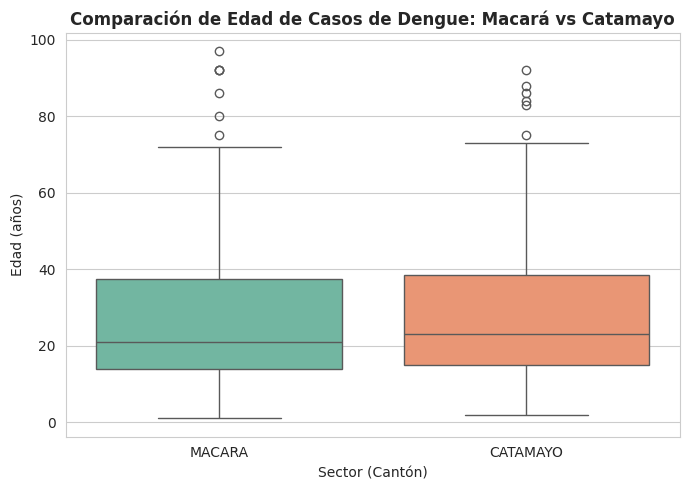

In [ ]:
# ==========================================================
# A/B TESTING: MACARÁ vs CATAMAYO (Edad de casos de dengue)
# ==========================================================

grupo_a = df_loja.loc[df_loja["Canton  Domic"] == "MACARA", "Edad"].values
grupo_b = df_loja.loc[df_loja["Canton  Domic"] == "CATAMAYO", "Edad"].values

alpha = 0.05

# ----------------------------------------------------------
# 1. Verificación del supuesto de homocedasticidad (Levene)
# ----------------------------------------------------------
lev_stat, lev_p = levene(grupo_a, grupo_b)
varianzas_homogeneas = lev_p > alpha

# ----------------------------------------------------------
# 2. Prueba T para dos muestras independientes
# ----------------------------------------------------------
t_ab, p_ab = ttest_ind(grupo_a, grupo_b, equal_var=varianzas_homogeneas)

# ----------------------------------------------------------
# Resultados
# ----------------------------------------------------------
print("=" * 65)
print(" A/B TESTING: SECTOR MACARÁ vs SECTOR CATAMAYO ")
print("=" * 65)

print("\nPrueba de Levene (homogeneidad de varianzas):")
print(f"  Estadístico = {lev_stat:.4f}   Valor-p = {lev_p:.4f}")
print(f"  ¿Varianzas homogéneas? {'Sí' if varianzas_homogeneas else 'No'}")

print("\nEstadísticos descriptivos:")
print(f"  Macará   -> n = {len(grupo_a)}, media = {np.mean(grupo_a):.2f}, s = {np.std(grupo_a, ddof=1):.2f}")
print(f"  Catamayo -> n = {len(grupo_b)}, media = {np.mean(grupo_b):.2f}, s = {np.std(grupo_b, ddof=1):.2f}")

print("\nResultado de la prueba T (independiente, bilateral):")
print(f"  Estadístico t = {t_ab:.4f}")
print(f"  Valor-p       = {p_ab:.4f}")

print("\nDecisión:")
if p_ab < alpha:
    print("  Se RECHAZA H0: existe diferencia significativa entre los sectores.")
else:
    print("  No se rechaza H0: no existe diferencia significativa entre los sectores.")
print("=" * 65)

# ----------------------------------------------------------
# Gráfico comparativo
# ----------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_loja[df_loja["Canton  Domic"].isin(["MACARA", "CATAMAYO"])],
    x="Canton  Domic", y="Edad", hue="Canton  Domic",
    palette="Set2", legend=False
)
plt.title("Comparación de Edad de Casos de Dengue: Macará vs Catamayo", fontsize=12, fontweight="bold")
plt.xlabel("Sector (Cantón)")
plt.ylabel("Edad (años)")
plt.tight_layout()
plt.show()


### **Interpretación**

La prueba de Levene arrojó un Valor-p de **0.5613** (> 0.05), por lo que se asume homogeneidad de varianzas entre ambos sectores, validando el uso de la prueba T con varianzas iguales.

El resultado de la prueba T independiente fue Valor-p ≈ **0.5108** (> $\alpha = 0.05$), por lo que **no se rechaza $H_0$**. No existe evidencia estadística suficiente para afirmar que la edad promedio de los pacientes con dengue difiera entre los sectores de Macará (≈ 28.16 años) y Catamayo (≈ 29.87 años). Ambos sectores comparten un perfil etario similar en los casos reportados.

---
# **🛠️ Tarea 3: Análisis de Varianza (ANOVA de 1 Factor) y Prueba Post-Hoc de Tukey**

### Planteamiento del problema

Se amplía la comparación a los **cinco cantones (sectores)** de la provincia de Loja con mayor número de casos registrados: **Macará, Catamayo, Loja, Zapotillo y Paltas**. El factor de agrupación es el **cantón de domicilio** (variable categórica con 5 niveles) y la variable dependiente es la **edad** del paciente.

### Hipótesis estadísticas

$$
H_0: \mu_{Macará} = \mu_{Catamayo} = \mu_{Loja} = \mu_{Zapotillo} = \mu_{Paltas}
$$

$$
H_1: \text{al menos una media poblacional difiere de las demás}
$$

### Verificación de supuestos del ANOVA

1. **Homogeneidad de varianzas** (Levene):
$$H_0^{Levene}: \sigma^2_1 = \sigma^2_2 = \dots = \sigma^2_k$$

2. **Normalidad de los residuos por grupo** (Shapiro-Wilk), y como respaldo no paramétrico ante posibles violaciones, se incluye la prueba de **Kruskal-Wallis**.

### Estadístico F

$$
F = \frac{MSB}{MSW} = \frac{SSB / (k-1)}{SSW / (N-k)}
$$

donde:

$$
SSB = \sum_{i=1}^{k} n_i (\bar{x}_i - \bar{x})^2 \qquad \text{(variabilidad entre grupos)}
$$

$$
SSW = \sum_{i=1}^{k} \sum_{j=1}^{n_i} (x_{ij} - \bar{x}_i)^2 \qquad \text{(variabilidad dentro de los grupos)}
$$

$k$ = número de grupos, $N$ = número total de observaciones.

### Prueba Post-Hoc de Tukey (HSD)

Si el ANOVA resulta significativo, la prueba de Tukey identifica **qué pares de grupos** difieren entre sí, controlando la tasa de error familiar (FWER):

$$
HSD = q_{\alpha,k,N-k}\sqrt{\frac{MSW}{n}}
$$

In [ ]:
# ==========================================================
# SELECCIÓN DE SECTORES (CANTONES) PARA EL ANOVA
# ==========================================================

cantones_analisis = ["MACARA", "CATAMAYO", "LOJA", "ZAPOTILLO", "PALTAS"]

df_anova = df_loja[df_loja["Canton  Domic"].isin(cantones_analisis)].copy()

grupos = [df_anova.loc[df_anova["Canton  Domic"] == c, "Edad"].values for c in cantones_analisis]

print("=" * 65)
print(" ESTADÍSTICOS DESCRIPTIVOS POR SECTOR ")
print("=" * 65)
resumen = df_anova.groupby("Canton  Domic")["Edad"].agg(["count", "mean", "std"]).loc[cantones_analisis]
print(resumen)

# ----------------------------------------------------------
# 1. Verificación de homogeneidad de varianzas (Levene)
# ----------------------------------------------------------
lev_stat, lev_p = levene(*grupos)

print("\nPrueba de Levene (homogeneidad de varianzas):")
print(f"  Estadístico = {lev_stat:.4f}   Valor-p = {lev_p:.4f}")

# ----------------------------------------------------------
# 2. Verificación de normalidad por grupo (Shapiro-Wilk)
# ----------------------------------------------------------
print("\nPrueba de normalidad Shapiro-Wilk por sector:")
for c, g in zip(cantones_analisis, grupos):
    sh_stat, sh_p = shapiro(g)
    print(f"  {c:10s} -> Estadístico = {sh_stat:.4f}, Valor-p = {sh_p:.4f}")


 ESTADÍSTICOS DESCRIPTIVOS POR SECTOR 
               count    mean     std
Canton  Domic                       
MACARA           167 28.1617 20.3308
CATAMAYO         106 29.8679 21.6874
LOJA              23 34.6957 16.9449
ZAPOTILLO         18 27.2778 19.2837
PALTAS             9 36.5556 20.5129

Prueba de Levene (homogeneidad de varianzas):
  Estadístico = 0.2768   Valor-p = 0.8929

Prueba de normalidad Shapiro-Wilk por sector:
  MACARA     -> Estadístico = 0.8669, Valor-p = 0.0000
  CATAMAYO   -> Estadístico = 0.8733, Valor-p = 0.0000
  LOJA       -> Estadístico = 0.9588, Valor-p = 0.4391
  ZAPOTILLO  -> Estadístico = 0.8978, Valor-p = 0.0526
  PALTAS     -> Estadístico = 0.8979, Valor-p = 0.2400


 TABLA ANOVA DE UN FACTOR 
                           sum_sq       df      F  PR(>F)
C(Q("Canton  Domic"))   1465.9294   4.0000 0.8697  0.4824
Residual              134005.4886 318.0000    NaN     NaN

Decisión:
  No se rechaza H0: no hay evidencia de diferencias entre sectores.

Prueba no paramétrica de Kruskal-Wallis (respaldo por posible no normalidad):
  Estadístico H = 5.9331   Valor-p = 0.2042


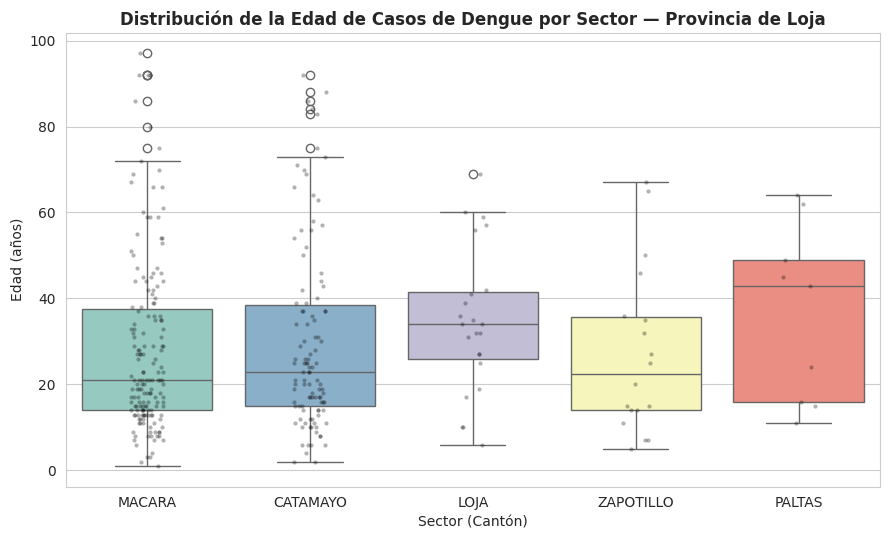

In [ ]:
# ==========================================================
# ANOVA DE UN FACTOR (statsmodels — abstracción avanzada vía OLS)
# ==========================================================

alpha = 0.05

modelo = ols('Edad ~ C(Q("Canton  Domic"))', data=df_anova).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

print("=" * 65)
print(" TABLA ANOVA DE UN FACTOR ")
print("=" * 65)
print(tabla_anova)

f_valor = tabla_anova["F"].iloc[0]
p_anova = tabla_anova["PR(>F)"].iloc[0]

print("\nDecisión:")
if p_anova < alpha:
    print("  Se RECHAZA H0: al menos un sector difiere en edad promedio.")
else:
    print("  No se rechaza H0: no hay evidencia de diferencias entre sectores.")

# ----------------------------------------------------------
# Robustez no paramétrica: Kruskal-Wallis
# ----------------------------------------------------------
kw_stat, kw_p = kruskal(*grupos)
print("\nPrueba no paramétrica de Kruskal-Wallis (respaldo por posible no normalidad):")
print(f"  Estadístico H = {kw_stat:.4f}   Valor-p = {kw_p:.4f}")
print("=" * 65)

# ----------------------------------------------------------
# Visualización comparativa
# ----------------------------------------------------------
plt.figure(figsize=(9, 5.5))
sns.boxplot(
    data=df_anova, x="Canton  Domic", y="Edad", hue="Canton  Domic",
    order=cantones_analisis, palette="Set3", legend=False
)
sns.stripplot(
    data=df_anova, x="Canton  Domic", y="Edad",
    order=cantones_analisis, color="black", alpha=0.3, size=3
)
plt.title("Distribución de la Edad de Casos de Dengue por Sector — Provincia de Loja", fontsize=12, fontweight="bold")
plt.xlabel("Sector (Cantón)")
plt.ylabel("Edad (años)")
plt.tight_layout()
plt.show()


 PRUEBA POST-HOC DE TUKEY (HSD) 
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2  meandiff p-adj   lower    upper  reject
----------------------------------------------------------
CATAMAYO      LOJA   4.8277 0.8449   -8.127 17.7825  False
CATAMAYO    MACARA  -1.7062 0.9628  -8.7002  5.2877  False
CATAMAYO    PALTAS   6.6876 0.8818  -12.866 26.2412  False
CATAMAYO ZAPOTILLO  -2.5901 0.9878 -16.9475 11.7672  False
    LOJA    MACARA   -6.534  0.608 -19.0598  5.9919  False
    LOJA    PALTAS   1.8599 0.9994 -20.2834 24.0032  False
    LOJA ZAPOTILLO  -7.4179 0.7806 -25.1411 10.3054  False
  MACARA    PALTAS   8.3939 0.7543 -10.8782  27.666  False
  MACARA ZAPOTILLO  -0.8839 0.9998 -14.8554 13.0876  False
  PALTAS ZAPOTILLO  -9.2778 0.8028 -32.2697 13.7142  False
----------------------------------------------------------


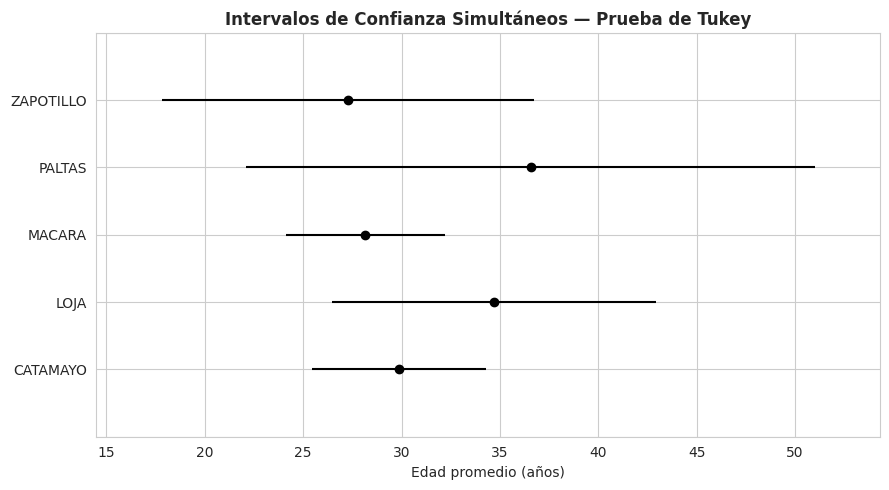

In [ ]:
# ==========================================================
# PRUEBA POST-HOC DE TUKEY (HSD)
# ==========================================================

tukey = pairwise_tukeyhsd(
    endog=df_anova["Edad"],
    groups=df_anova["Canton  Domic"],
    alpha=0.05
)

print("=" * 65)
print(" PRUEBA POST-HOC DE TUKEY (HSD) ")
print("=" * 65)
print(tukey)

# Visualización de intervalos de confianza de Tukey
fig = tukey.plot_simultaneous(figsize=(9, 5))
plt.title("Intervalos de Confianza Simultáneos — Prueba de Tukey", fontsize=12, fontweight="bold")
plt.xlabel("Edad promedio (años)")
plt.tight_layout()
plt.show()


### **Interpretación**

**Verificación de supuestos:** la prueba de Levene ($p \approx 0.8929$) confirma la homogeneidad de varianzas entre los cinco sectores. La prueba de Shapiro-Wilk indica que los grupos con mayor tamaño muestral (Macará y Catamayo) presentan una ligera desviación de la normalidad ($p < 0.05$), atribuible a la naturaleza asimétrica de la variable edad y a los tamaños muestrales grandes de esos grupos; sin embargo, el ANOVA es razonablemente robusto ante esta violación cuando los tamaños de muestra son grandes y las varianzas son homogéneas. Como respaldo, la prueba no paramétrica de **Kruskal-Wallis** ($p \approx 0.2042$) confirma la misma conclusión que el ANOVA paramétrico.

**Resultado del ANOVA:** se obtuvo un estadístico $F \approx 0.8697$ con un Valor-p $\approx 0.4824$, muy superior a $\alpha = 0.05$. Por lo tanto, **no se rechaza $H_0$**: no existe evidencia estadística suficiente para afirmar que la edad promedio de los pacientes con dengue difiera entre los sectores de Macará, Catamayo, Loja, Zapotillo y Paltas.

**Prueba de Tukey:** de forma consistente, ninguna de las diez comparaciones por pares entre sectores resultó significativa (todos los `p-adj` > 0.05 y todos los intervalos de confianza de las diferencias de medias contienen al cero), confirmando que no hay evidencia de heterogeneidad etaria entre los sectores geográficos analizados de la provincia de Loja.

**Implicación práctica:** dado que el perfil etario de los casos de dengue es estadísticamente homogéneo entre los distintos sectores de Loja, las estrategias de vigilancia y prevención epidemiológica basadas en grupo etario **no requieren diferenciarse por cantón**; los recursos pueden distribuirse siguiendo un criterio etario único y válido para toda la provincia.

---
# 📊 **Conclusiones Generales**

1. **Prueba unimuestral (T de Student):** la edad promedio de los casos de dengue en la provincia de Loja (≈ 29.15 años) no difiere significativamente del valor de referencia de 30 años ($p = 0.4333$).

2. **A/B Testing (Macará vs Catamayo):** no se encontró diferencia significativa en la edad promedio entre los dos sectores con mayor incidencia de casos ($p = 0.5108$), tras verificar la homogeneidad de varianzas mediante la prueba de Levene.

3. **ANOVA de un factor + Tukey:** al extender la comparación a cinco sectores (Macará, Catamayo, Loja, Zapotillo, Paltas), el análisis de varianza no detectó diferencias significativas entre las medias ($F = 0.8697$, $p = 0.4824$), resultado corroborado tanto por la prueba post-hoc de Tukey (ninguna comparación por pares significativa) como por la prueba no paramétrica de Kruskal-Wallis.

En conjunto, los resultados indican que el **perfil etario de los pacientes con dengue en la provincia de Loja es homogéneo** a través de sus distintos sectores geográficos, lo que sugiere que los factores de riesgo asociados a la edad actúan de manera similar independientemente del microclima o cantón de residencia dentro de la provincia.